In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data (no scaling needed — Random Forest is tree-based)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")
print(f"Classes          : {iris.target_names}")

Training samples : 120
Testing  samples : 30
Features         : 4
Classes          : ['setosa' 'versicolor' 'virginica']


Random Forest Accuracy: 90.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



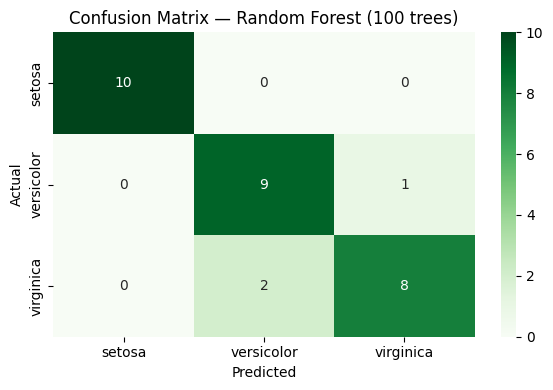

In [3]:
# Train Random Forest with 100 trees (default)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=iris.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title("Confusion Matrix — Random Forest (100 trees)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

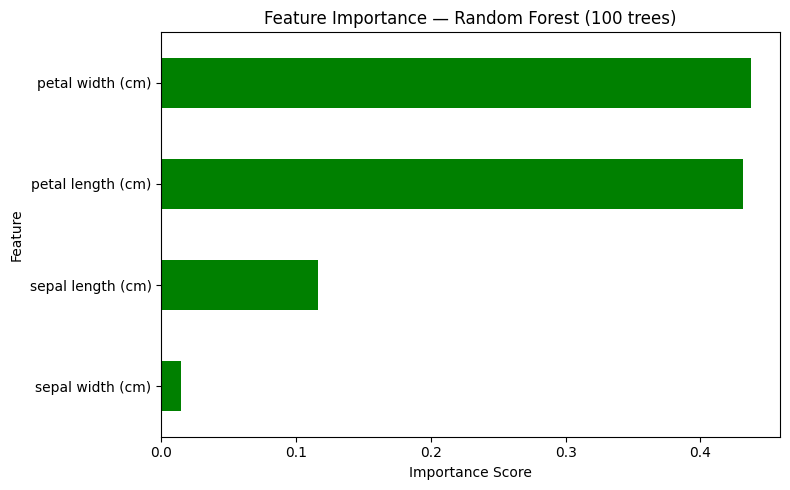

Feature Importance Scores:
petal width (cm)     0.437185
petal length (cm)    0.431466
sepal length (cm)    0.116349
sepal width (cm)     0.015000
dtype: float64


In [4]:
# Random Forest provides built-in feature importance
feature_importance = pd.Series(
    rf.feature_importances_,
    index=iris.feature_names
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind="barh", color="green")
plt.title("Feature Importance — Random Forest (100 trees)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Feature Importance Scores:")
print(feature_importance.sort_values(ascending=False))

n_estimators=  10 → Train: 100.00%  |  Test: 96.67%
n_estimators=  50 → Train: 100.00%  |  Test: 90.00%
n_estimators= 100 → Train: 100.00%  |  Test: 90.00%
n_estimators= 200 → Train: 100.00%  |  Test: 90.00%
n_estimators= 500 → Train: 100.00%  |  Test: 93.33%


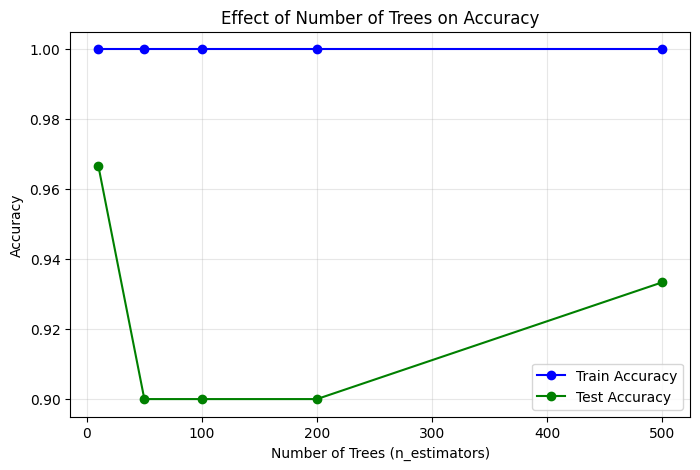

In [5]:
estimators = [10, 50, 100, 200, 500]
train_accuracies = []
test_accuracies  = []

for n in estimators:
    rf_n = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_n.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, rf_n.predict(X_train))
    test_acc  = accuracy_score(y_test,  rf_n.predict(X_test))

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"n_estimators={n:4d} → Train: {train_acc*100:.2f}%  |  Test: {test_acc*100:.2f}%")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(estimators, train_accuracies, marker="o", label="Train Accuracy", color="blue")
plt.plot(estimators, test_accuracies,  marker="o", label="Test Accuracy",  color="green")
plt.title("Effect of Number of Trees on Accuracy")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Create some unseen sample data points
unseen_data = np.array([
    [5.1, 3.5, 1.4, 0.2],   # likely Setosa
    [6.2, 2.9, 4.3, 1.3],   # likely Versicolor
    [7.3, 3.0, 6.3, 1.8],   # likely Virginica
])

# Predict
predictions = rf.predict(unseen_data)
probabilities = rf.predict_proba(unseen_data)

print("Predictions on Unseen Data:")
print("-" * 50)
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    print(f"\nSample {i+1}: {unseen_data[i]}")
    print(f"  Predicted Class : {iris.target_names[pred]}")
    print(f"  Confidence      : {prob.max()*100:.1f}%")
    print(f"  Probabilities   : Setosa={prob[0]:.2f}, Versicolor={prob[1]:.2f}, Virginica={prob[2]:.2f}")

Predictions on Unseen Data:
--------------------------------------------------

Sample 1: [5.1 3.5 1.4 0.2]
  Predicted Class : setosa
  Confidence      : 100.0%
  Probabilities   : Setosa=1.00, Versicolor=0.00, Virginica=0.00

Sample 2: [6.2 2.9 4.3 1.3]
  Predicted Class : versicolor
  Confidence      : 99.0%
  Probabilities   : Setosa=0.00, Versicolor=0.99, Virginica=0.01

Sample 3: [7.3 3.  6.3 1.8]
  Predicted Class : virginica
  Confidence      : 100.0%
  Probabilities   : Setosa=0.00, Versicolor=0.00, Virginica=1.00


Single Decision Tree Accuracy : 93.33%
Random Forest Accuracy        : 90.00%


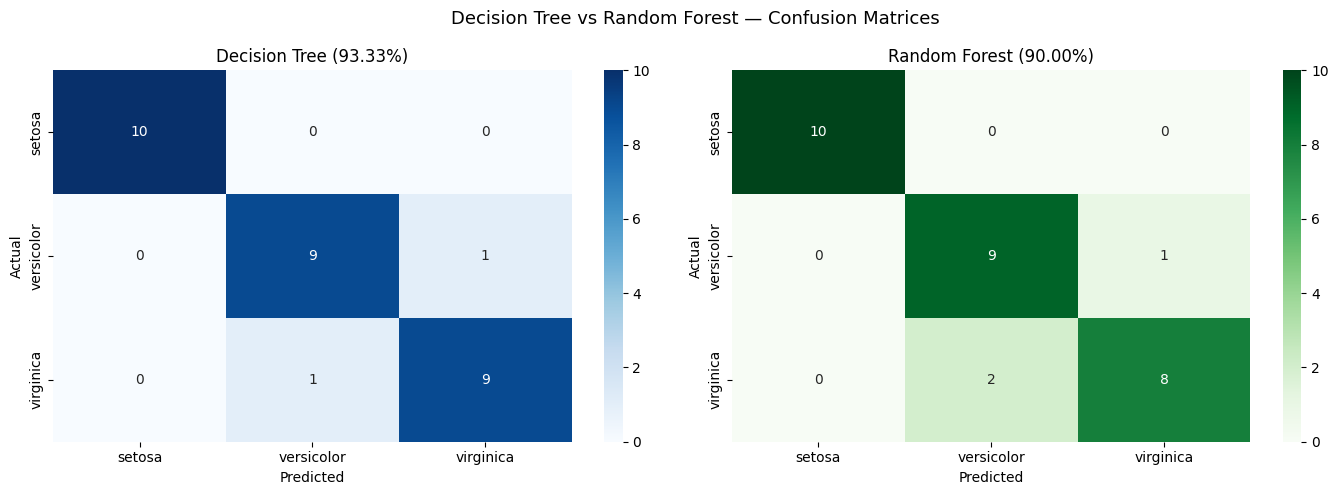


Overfitting Analysis:
Decision Tree → Train: 100.00%  Test: 93.33%  Gap: 6.67%
Random Forest → Train: 100.00%  Test: 90.00%  Gap: 10.00%


In [7]:
# Train single Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Random Forest already trained (rf, 100 trees)
dt_acc = accuracy_score(y_test, y_pred_dt)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"Single Decision Tree Accuracy : {dt_acc*100:.2f}%")
print(f"Random Forest Accuracy        : {rf_acc*100:.2f}%")

# Side by side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d",
            cmap="Blues", ax=axes[0],
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
axes[0].set_title(f"Decision Tree ({dt_acc*100:.2f}%)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d",
            cmap="Greens", ax=axes[1],
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
axes[1].set_title(f"Random Forest ({rf_acc*100:.2f}%)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.suptitle("Decision Tree vs Random Forest — Confusion Matrices", fontsize=13)
plt.tight_layout()
plt.show()

# Overfitting comparison
dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
rf_train_acc = accuracy_score(y_train, rf.predict(X_train))

print(f"\nOverfitting Analysis:")
print(f"Decision Tree → Train: {dt_train_acc*100:.2f}%  Test: {dt_acc*100:.2f}%  Gap: {(dt_train_acc-dt_acc)*100:.2f}%")
print(f"Random Forest → Train: {rf_train_acc*100:.2f}%  Test: {rf_acc*100:.2f}%  Gap: {(rf_train_acc-rf_acc)*100:.2f}%")